In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
k = 1.0     # spring constant (N/m)
m = 1.0     # mass (kg)
omega0 = np.sqrt(k / m)   # natural frequency
T = 2 * np.pi / omega0      # period

# Initial conditions
x0 = 1.0    # initial displacement (m)
v0 = 0.0    # released from rest

# Exact solution for comparison
def exact_x(t):
    return x0 * np.cos(omega0 * t)

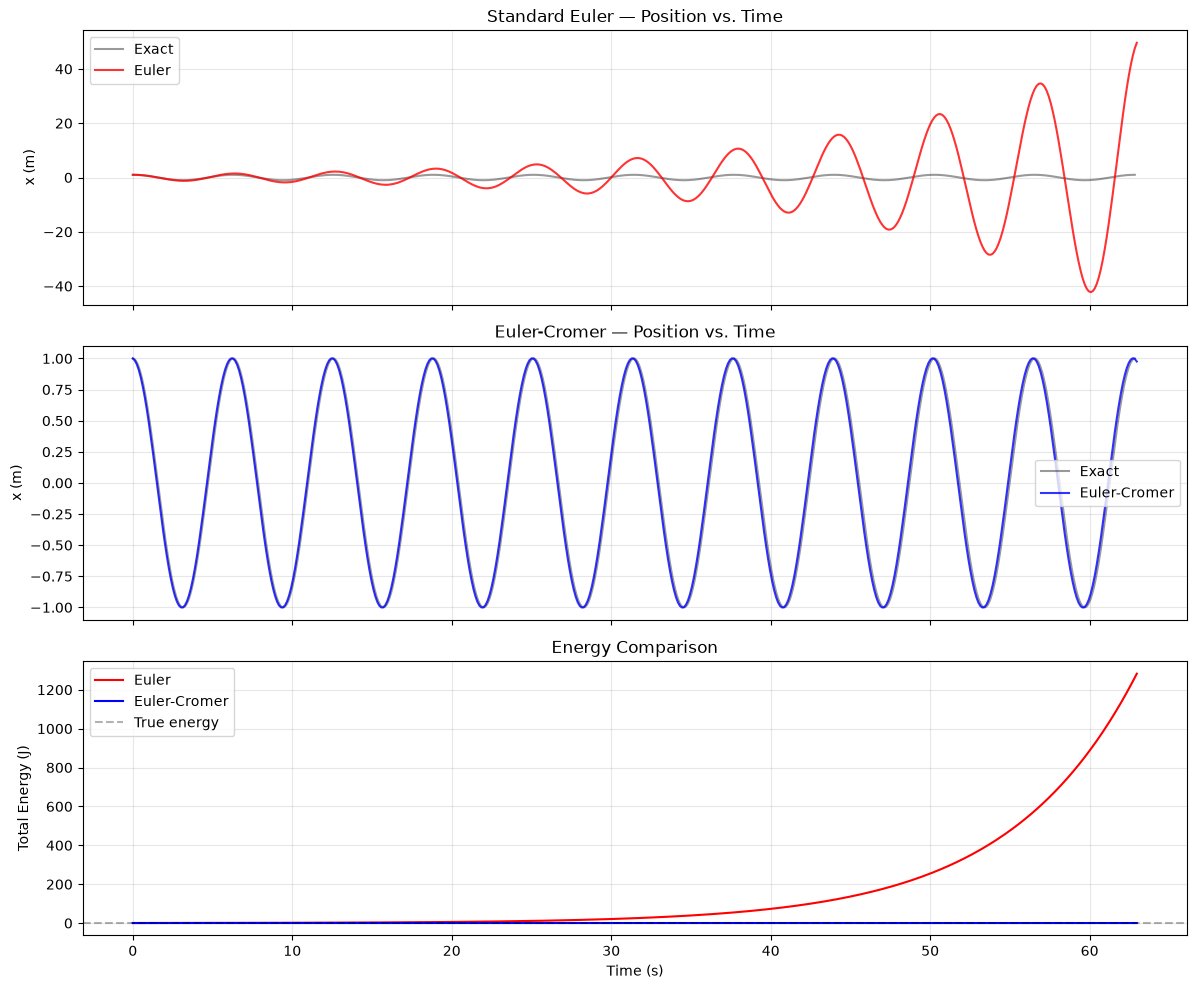

In [2]:
def simulate_sho(method, dt, n_periods=10):
    """Simulate SHO. Returns t, x, v, E arrays."""
    t_max = n_periods * T
    x, v = x0, v0
    ts, xs, vs, Es = [0], [x], [v], [0.5*k*x**2 + 0.5*m*v**2]
    t = 0.0

    while t < t_max:
        a = -(k / m) * x

        if method == 'euler':
            x_new = x + v * dt
            v_new = v + a * dt
            x, v = x_new, v_new
        elif method == 'euler-cromer':
            v = v + a * dt       # velocity first
            x = x + v * dt       # then position with new v

        t += dt
        E = 0.5 * k * x**2 + 0.5 * m * v**2
        ts.append(t); xs.append(x); vs.append(v); Es.append(E)

    return np.array(ts), np.array(xs), np.array(vs), np.array(Es)

# Run both with dt = T/50 (moderately coarse)
dt = T / 50
t_e, x_e, v_e, E_e = simulate_sho('euler', dt)
t_ec, x_ec, v_ec, E_ec = simulate_sho('euler-cromer', dt)
t_exact = np.linspace(0, 10*T, 2000)

# ─── Plot: x(t) comparison ────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].plot(t_exact, exact_x(t_exact), 'k-', alpha=0.4, label='Exact')
axes[0].plot(t_e, x_e, 'r-', alpha=0.8, label='Euler')
axes[0].set_ylabel('x (m)')
axes[0].set_title('Standard Euler — Position vs. Time')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_exact, exact_x(t_exact), 'k-', alpha=0.4, label='Exact')
axes[1].plot(t_ec, x_ec, 'b-', alpha=0.8, label='Euler-Cromer')
axes[1].set_ylabel('x (m)')
axes[1].set_title('Euler-Cromer — Position vs. Time')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(t_e, E_e, 'r-', label='Euler')
axes[2].plot(t_ec, E_ec, 'b-', label='Euler-Cromer')
axes[2].axhline(y=E_e[0], color='k', linestyle='--', alpha=0.3, label='True energy')
axes[2].set_xlabel('Time (s)')
axes[2].set_ylabel('Total Energy (J)')
axes[2].set_title('Energy Comparison')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()